<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
import sys
import os
import site

!{sys.executable} -m pip uninstall -y \
    sentence-transformers \
    huggingface-hub \
    transformers \
    torch torchvision torchaudio \
    langchain langchain-community langchain-core \
    faiss-cpu \
    ragatouille \
    ragas \
    accelerate \
    bitsandbytes \
    2>/dev/null || true

!{sys.executable} -m pip cache purge

# 2. PyTorch для CPU 
!{sys.executable} -m pip install --no-cache-dir \
    torch==2.2.0 \
    torchvision==0.17.0 \
    torchaudio==2.2.0 \
    --index-url https://download.pytorch.org/whl/cpu

# 3. huggingface-hub 
!{sys.executable} -m pip install --no-cache-dir huggingface-hub==0.19.4

# 4. sentence-transformers
!{sys.executable} -m pip uninstall -y sentence-transformers
!{sys.executable} -m pip install --no-cache-dir sentence-transformers>=2.4.0
# 5. Устанавливаем transformers
!{sys.executable} -m pip install --no-cache-dir transformers==4.36.2

# 6. accelerate
!{sys.executable} -m pip install --no-cache-dir accelerate==0.25.0

# 7. LangChain стек
!{sys.executable} -m pip install --no-cache-dir \
    langchain==0.1.20 \
    langchain-community==0.0.38 \
    langchain-core==0.1.53 \
    faiss-cpu==1.8.0

# 8. Устанавливаем ragatouille
!{sys.executable} -m pip install --no-cache-dir ragatouille==0.0.8

# 9. Возвращаем huggingface-hub
!{sys.executable} -m pip install --no-cache-dir --force-reinstall huggingface-hub==0.19.4

# 10. Патч для ragatouille
for path in site.getsitepackages():
    ragatouille_path = os.path.join(path, 'ragatouille')
    if os.path.exists(ragatouille_path):
        patch_file = os.path.join(ragatouille_path, 'utils.py')
        if os.path.exists(patch_file):
            with open(patch_file, 'r') as f:
                content = f.read()
            if 'from huggingface_hub import cached_download' in content:
                content = content.replace(
                    'from huggingface_hub import cached_download',
                    'from huggingface_hub import hf_hub_download as cached_download'
                )
                with open(patch_file, 'w') as f:
                    f.write(content)
                print(f"Патч применен для {patch_file}")
        break

# 11. Остальные пакеты (без CUDA-зависимостей)
!{sys.executable} -m pip install --no-cache-dir \
    umap-learn==0.5.3 \
    gdown plotly matplotlib tqdm \
    scikit-learn==1.3.2 \
    numpy==1.26.4 \
    pandas==2.1.4 \
    scipy==1.12.0

In [ ]:
import os
os._exit(0)

In [1]:
import sys
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings  
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
2026-05-02 11:46:20.421721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777722380.448955    2808 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777722380.456813    2808 cuda_blas.cc:14

In [2]:
from langchain.text_splitter import RecursiveCharacterTextSplitter, SpacyTextSplitter

## Загрузка данных (4 балла)

In [3]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=d9d863b3-5ade-4db3-91cd-1002221eafa1
To: /kaggle/working/file.csv
100%|██████████| 672M/672M [00:02<00:00, 307MB/s] 


In [4]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


In [5]:
data = data.drop(['Unnamed: 0'], axis=1)

In [6]:
print(f"Всего записей: {len(data)}")
print(f"Колонки: {data.columns.tolist()}")

print(f"\nПропуски в Name: {data['Name'].isna().sum()}")
print(f"\nПропуски в WikiData: {data['WikiData'].isna().sum()}")
print(f"\nПропуски в City: {data['City'].isna().sum()}")
print(f"\nПропуски в Lon: {data['Lon'].isna().sum()}")
print(f"\nПропуски в Lat: {data['Lat'].isna().sum()}")
print(f"\nПропуски в City: {data['Name'].isna().sum()}")
print(f"\nПропуски в описаниях: {data['description'].isna().sum()}")
print(f"\nПропуски в image: {data['image'].isna().sum()}")
print(f"\nПропуски в en_txt: {data['en_txt'].isna().sum()}")

Всего записей: 14634
Колонки: ['Name', 'WikiData', 'City', 'Lon', 'Lat', 'description', 'image', 'en_txt']

Пропуски в Name: 0

Пропуски в WikiData: 2556

Пропуски в City: 0

Пропуски в Lon: 0

Пропуски в Lat: 0

Пропуски в City: 0

Пропуски в описаниях: 2556

Пропуски в image: 0

Пропуски в en_txt: 0


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [7]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [8]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

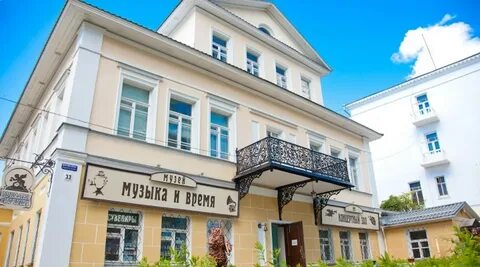

In [9]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [10]:
def to_string(val):
  if pd.isna(val):
    return ''
  return str(val)

In [11]:
# your code here
data['combined_text'] = data.apply(
    lambda row: to_string(row['Name']) + ' ' + to_string(row['description']) + ' ' + to_string(row['City']) + ' ' + to_string(row['en_txt']),
    axis=1
)

In [12]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

russian_stop_words = set(stopwords.words('russian'))
english_stop_words = set(stopwords.words('english'))

stopwords = russian_stop_words.union(english_stop_words)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^а-яa-z\s]', '', text) # удаляет все символы, кроме русских и английских букв и пробелов
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) >= 3]
    return ' '.join(words)

In [14]:
data['cleaned_text'] = data['combined_text'].apply(clean_text)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = data['cleaned_text'].tolist()

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(corpus) # TF-IDF матрица

feature_names = vectorizer.get_feature_names_out() # названия признаков (слова) для анализа текстов

In [16]:
mean_tfidf = tfidf_matrix.mean(axis=0).tolist()[0]

word_scores = dict(zip(feature_names, mean_tfidf))

sorted_words = sorted(word_scores.items(), key = lambda x: x[1], reverse = True)

for i, (word, score) in enumerate(sorted_words[:30], 1):
    word_idx = vectorizer.vocabulary_.get(word) 
    doc_count = (tfidf_matrix[:, word_idx] > 0).sum() # в скольких документах встречается слово (столбец слова по всем документам, по весу: tf-idf > 0 => слово встречается)
    
    print(f"{i}. '{word}' - TF-IDF: {score:.4f}, встречается в {doc_count} документах")

1. 'building' - TF-IDF: 0.0462, встречается в 6330 документах
2. 'arafed' - TF-IDF: 0.0454, встречается в 6215 документах
3. 'ярославль' - TF-IDF: 0.0445, встречается в 4372 документах
4. 'владимир' - TF-IDF: 0.0381, встречается в 3511 документах
5. 'екатеринбург' - TF-IDF: 0.0349, встречается в 3282 документах
6. 'нижний' - TF-IDF: 0.0338, встречается в 3469 документах
7. 'новгород' - TF-IDF: 0.0338, встречается в 3469 документах
8. 'церковь' - TF-IDF: 0.0334, встречается в 2024 документах
9. 'view' - TF-IDF: 0.0306, встречается в 2907 документах
10. 'large' - TF-IDF: 0.0300, встречается в 2815 документах
11. 'храм' - TF-IDF: 0.0288, встречается в 1767 документах
12. 'white' - TF-IDF: 0.0279, встречается в 2430 документах
13. 'ярославле' - TF-IDF: 0.0277, встречается в 2101 документах
14. 'clock' - TF-IDF: 0.0273, встречается в 2309 документах
15. 'екатеринбурге' - TF-IDF: 0.0270, встречается в 2190 документах
16. 'church' - TF-IDF: 0.0267, встречается в 2278 документах
17. 'дом' - TF

**очистка от GARBAGE_WORDS**

In [17]:
GARBAGE_WORDS = {
    'arafed', 'building',
    'large', 'view',
    'front', 'top',
    'man', 'people',
    'standing', 'city',
    'здание',
}

all_words = set(vectorizer.get_feature_names_out())
keep_words = [w for w in all_words if w not in GARBAGE_WORDS]

In [18]:
vectorizer_clean = TfidfVectorizer(vocabulary=keep_words)
tfidf_matrix_clean = vectorizer_clean.fit_transform(corpus)

feature_names = vectorizer_clean.get_feature_names_out()

mean_tfidf = tfidf_matrix_clean.mean(axis=0).A1  # .A1 - альтернатива .toarray().flatten() - преобразование матрицы в одномерный массив numpy (A - двумерный)

word_scores = dict(zip(feature_names, mean_tfidf))

sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)

for i, (word, score) in enumerate(sorted_words[:30], 1):
    word_idx = vectorizer_clean.vocabulary_.get(word)
    doc_count = (tfidf_matrix_clean[:, word_idx].toarray() > 0).sum()

    print(f"{i}. '{word}' - TF-IDF: {score:.4f}, встречается в {doc_count} документах")

1. 'ярославль' - TF-IDF: 0.0455, встречается в 4372 документах
2. 'владимир' - TF-IDF: 0.0395, встречается в 3511 документах
3. 'екатеринбург' - TF-IDF: 0.0362, встречается в 3282 документах
4. 'новгород' - TF-IDF: 0.0346, встречается в 3469 документах
5. 'нижний' - TF-IDF: 0.0346, встречается в 3469 документах
6. 'церковь' - TF-IDF: 0.0342, встречается в 2024 документах
7. 'храм' - TF-IDF: 0.0295, встречается в 1767 документах
8. 'white' - TF-IDF: 0.0288, встречается в 2430 документах
9. 'ярославле' - TF-IDF: 0.0286, встречается в 2101 документах
10. 'clock' - TF-IDF: 0.0283, встречается в 2309 документах
11. 'екатеринбурге' - TF-IDF: 0.0282, встречается в 2190 документах
12. 'дом' - TF-IDF: 0.0274, встречается в 1364 документах
13. 'church' - TF-IDF: 0.0274, встречается в 2278 документах
14. 'green' - TF-IDF: 0.0258, встречается в 1632 документах
15. 'tower' - TF-IDF: 0.0258, встречается в 1953 документах
16. 'башня' - TF-IDF: 0.0253, встречается в 892 документах
17. 'музей' - TF-IDF

In [19]:
duplicates = data.groupby(['WikiData']).size().reset_index(name='count')
print(duplicates[duplicates['count'] > 1].head())

     WikiData  count
0  Q100270892     28
1  Q100701435     30
2  Q100882660     30
3  Q104554178     57
4  Q104776528     29


In [20]:
def best_description(group):
    return group.loc[group['en_txt'].str.len().idxmax()]

deduplicated_data = data.groupby(['WikiData'], group_keys=False).apply(
    best_description
).reset_index(drop=True)

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [21]:
from langchain_core.documents import Document as LangchainDocument
from tqdm.notebook import tqdm

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(
        page_content=row['cleaned_text'],
        metadata={
            "name": row['Name'],
            "description": row['description'],
            "city": row['City'],
            "index": idx
        }
    )
    for idx, row in tqdm(deduplicated_data.iterrows(), total=len(deduplicated_data))
] # .iterrows() - метод Pandas, который перебирает строки DataFrame по одной

print(f"Создано {len(RAW_KNOWLEDGE_BASE)} документов")

  0%|          | 0/296 [00:00<?, ?it/s]

Создано 296 документов


In [22]:
deduplicated_data = deduplicated_data.drop('combined_text', axis=1)

In [23]:
deduplicated_data

,Name,WikiData,City,Lon,Lat,description,image,en_txt,cleaned_text
0,Нижегородский Кремль,Q100270892,Нижний Новгород,44.005554,56.327255,"историческое здание в Нижнем Новгороде, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed staircases leading up to a grassy hill ...,нижегородский кремль историческое здание нижне...
1,Гарнизонная казарма,Q100701435,Нижний Новгород,44.004299,56.327614,"здание в Нижегородском кремле, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,an aerial view of a building that has been des...,гарнизонная казарма здание нижегородском кремл...
2,Губернаторский сад,Q100882660,Нижний Новгород,44.005272,56.329803,"парк в Нижегородском кремле, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a fountain in the middle of a courtya...,губернаторский сад парк нижегородском кремле р...
3,Церковь Николы в Меленках,Q104554178,Ярославль,39.834522,57.609947,Православный храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,an old picture of a large building with two to...,церковь николы меленках православный храм ярос...
4,Церковь в честь Преображения Господня,Q104776528,Нижний Новгород,44.072117,56.318909,Спасо-Преображенская церковь (Старые Печёры),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a small wooden building with a white ...,церковь честь преображения господня спасопреоб...
...,...,...,...,...,...,...,...,...,...
291,Здание Удельной конторы,Q97999957,Нижний Новгород,44.021175,56.325153,Здание Удельной конторы,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed picture of a building with a horse draw...,здание удельной конторы здание удельной контор...
292,Дом архитектора,Q98381215,Нижний Новгород,44.009949,56.329483,Жилой дом горьковского архитектора А. А. Яковлева,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a spiral staircase with a glass raili...,дом архитектора жилой дом горьковского архитек...
293,Рекорд,Q99522676,Нижний Новгород,44.004810,56.323887,Общежитие института инженеров водного транспор...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a street with a building and pe...,рекорд общежитие института инженеров водного т...
294,Дворец вице-губернатора,Q99622643,Нижний Новгород,44.003147,56.327217,"административное здание в Нижнем Новгороде, Ро...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a building through a stone arch...,дворец вицегубернатора административное здание...


**RAG**

In [24]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

In [25]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

vector_store = FAISS.from_documents(RAW_KNOWLEDGE_BASE, embeddings)

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [26]:
import torch
from ragatouille import RAGPretrainedModel

try:
    reranker = RAGPretrainedModel.from_pretrained(
        "colbert-ir/colbertv2.0",
        index_root="./colbert_index",
    )
    print(" ColBERT reranker загружен на CPU!")
    
except Exception as e:
    print(f" Ошибка: {e}")
    reranker = None

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


[May 02, 11:47:04] Loading segmented_maxsim_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...
 ColBERT reranker загружен на CPU!


/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:126: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [27]:
!{sys.executable} -m pip install llama-cpp-python

In [28]:
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain_community.llms import LlamaCpp
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="IlyaGusev/saiga_llama3_8b_gguf",
    filename="model-q4_K.gguf")

llm = LlamaCpp(
    model_path=model_path,
    temperature=0.3,
    max_tokens=512,
    n_ctx=4096,
    top_p = 0.9, # топ слов
    n_gpu_layers=0,  
    verbose=False # блокирование отладочного вывода
)

llama_context: n_ctx_seq (4096) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


In [29]:
def custom_rag_query(question, with_reranking=False, k=5, llm_model=None):
    
    # поиск документов
    docs_with_scores = vector_store.similarity_search_with_score(question, k=k)
    source_documents = [doc for doc, score in docs_with_scores]
    
    # формирование контекста
    context_parts = []
    total_len = 0
    for doc in source_documents:
        text = doc.page_content[:1000]  # ограничение документа
        if total_len + len(text) < 3000:  
            context_parts.append(text)
            total_len += len(text)
    
    context = "\n\n".join(context_parts)
    
    # Шаг 3: Промпт 
    prompt = f"""<|start_header_id|>system<|end_header_id|>

Ты - опытный туристический гид. Отвечай на вопрос, используя ТОЛЬКО информацию из контекста. Если ответа нет - скажи "Информация не найдена".<|eot_id|>
<|start_header_id|>user<|end_header_id|>

Контекст:
{context}

Вопрос: {question}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
"""
    
    # генерация ответа
    try:
        response = llm_model.invoke(prompt)
        # очищение ответа от промпта
        response = response.replace(prompt, "").strip()
        # обрезание ответа
        if len(response) > 2000:
            response = response[:2000] + "..."
    except Exception as e:
        print(f"Ошибка: {e}")
        response = f"Найдено {len(source_documents)} результатов"
    
    return {
        "response": response,
        "source_documents": source_documents,
        "scores": [score for doc, score in docs_with_scores]
    }

In [30]:
# тестовые вопросы
test_questions = [
    "Какие достопримечательности есть в Екатеринбурге?",
    "Расскажи подробнее о Храме-на-Крови в Екатеринбурге",
    "Что посмотреть в Ярославле?",
    "Какие музеи есть в Нижнем Новгороде?",
]

# тестирование
for question in test_questions:
    print("\n" + "="*60)
    print(f"Вопрос: {question}")
    print("="*60)

    result = custom_rag_query(question, with_reranking=True, llm_model=llm)

    print(f"\nОтвет: {result['response']}")


Вопрос: Какие достопримечательности есть в Екатеринбурге?

Ответ: Информация не найдена.

Вопрос: Расскажи подробнее о Храме-на-Крови в Екатеринбурге

Ответ: Информация не найдена.

Вопрос: Что посмотреть в Ярославле?

Ответ: В Ярославле можно посетить множество исторических и культурных достопримечательностей. Вот некоторые из них:

1. **Спасо-Преображенский собор** - один из самых известных храмов России, расположенный на берегу Волги.

2. **Печерский Вознесенский монастырь** - один из древнейших и наиболее значимых монастырей в России, расположенный в центре Ярославля.

3. **Российский государственный академический театр драмы имени Фёдора Волкова** - один из старейших и самых известных театров России, расположенный на берегу Волги.

Эти достопримечательности представляют собой уникальный культурный и исторический опыт Ярославля.

Вопрос: Какие музеи есть в Нижнем Новгороде?

Ответ: Информация не найдена.


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [31]:
!{sys.executable} -m pip uninstall -y umap-learn
!{sys.executable} -m pip install umap-learn==0.5.6

Found existing installation: umap-learn 0.5.3
Uninstalling umap-learn-0.5.3:
  Successfully uninstalled umap-learn-0.5.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.5 MB/s eta 0:00:00


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


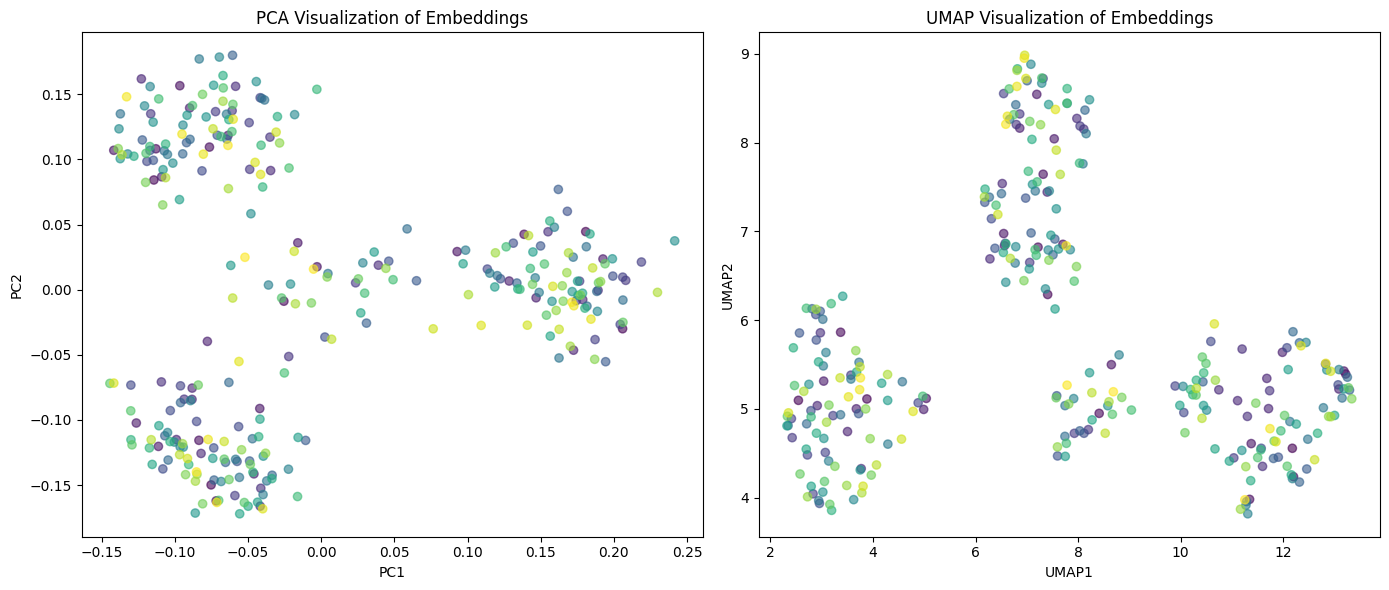

In [32]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np
import torch

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('intfloat/multilingual-e5-small')

sample_size = 500
sample_data = deduplicated_data.sample(n=min(sample_size, len(deduplicated_data)), random_state=42)

embeddings = model.encode(sample_data['cleaned_text'].tolist(), show_progress_bar=True)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

# UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_reducer.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA plot
axes[0].scatter(pca_result[:, 0], pca_result[:, 1], c=range(len(pca_result)), cmap='viridis', alpha=0.6)
axes[0].set_title('PCA Visualization of Embeddings')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# UMAP plot
axes[1].scatter(umap_result[:, 0], umap_result[:, 1], c=range(len(umap_result)), cmap='viridis', alpha=0.6)
axes[1].set_title('UMAP Visualization of Embeddings')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

есть кластеры => модель выявила структуру, цвет отражает просто порядковый номер и не имеет значения

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)  # работает в исходной размерности

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(pca_result[:, 0], pca_result[:, 1], 
                           c=cluster_labels, cmap='tab10', alpha=0.6)
axes[0].set_title('PCA - Colored by K-Means Clusters')

scatter2 = axes[1].scatter(umap_result[:, 0], umap_result[:, 1], 
                           c=cluster_labels, cmap='tab10', alpha=0.6)
axes[1].set_title('UMAP - Colored by K-Means Clusters')

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

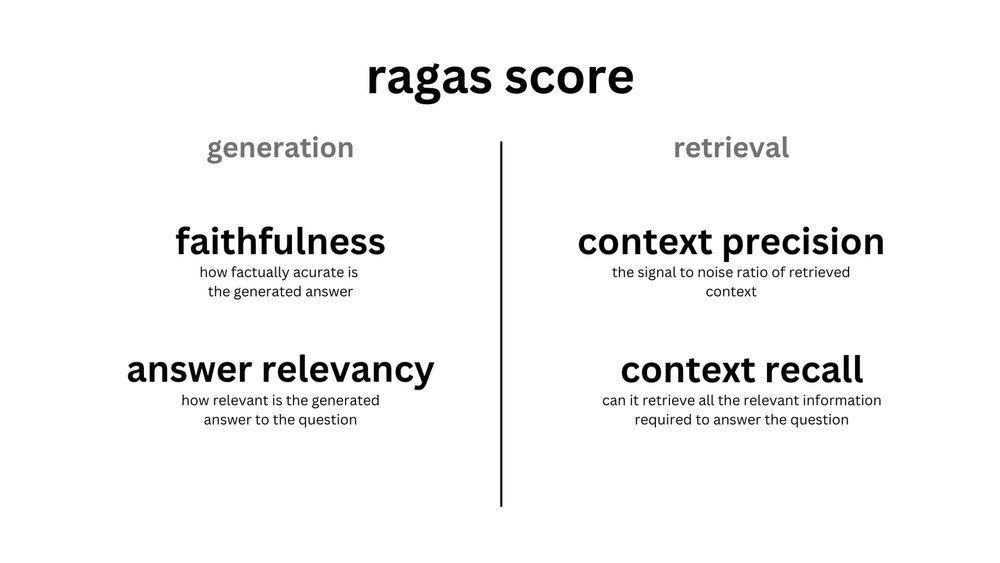

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [33]:
!{sys.executable} -m pip install --no-cache-dir \
    ragas==0.0.22 \
    datasets==2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 177.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.2
    Uninstalling packaging-26.2:
      Successfully uninstalled packaging-26.2
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
nilearn 0.13.1 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incom

In [34]:
import pandas as pd
import numpy as np
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
    answer_similarity,
    answer_correctness
)
from datasets import Dataset

In [36]:
# тестовые данные для RAGAS
test_data = []

# 100 случайных строк из deduplicated_data
sample_for_eval = deduplicated_data.sample(n=min(20, len(deduplicated_data)), random_state=42)

for idx, row in sample_for_eval.iterrows():
    question = f"Расскажи о достопримечательности {row['Name']} в городе {row['City']}"

    rag_result = custom_rag_query(question, with_reranking=False, k=5, llm_model=llm)

    # контексты
    contexts = [doc.page_content for doc in rag_result['source_documents']]

    # Ground truth 
    ground_truth = row['en_txt']

    test_data.append({
        'question': question,
        'answer': rag_result['response'],
        'contexts': contexts,
        'ground_truth': ground_truth,
        'ground_truths': [ground_truth]  
    })

from datasets import Dataset
ragas_dataset = Dataset.from_list(test_data)

print(f"Создано {len(ragas_dataset)} примеров для оценки RAGAS")

Создано 20 примеров для оценки RAGAS


# Протестируйте ваш RAG (3 балла)

In [37]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

eval_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

scores = {
    'answer_relevancy': [],
    'faithfulness': [],
    'context_precision': []
}

for item in test_data:
    # релевантность ответа вопросу
    q_emb = eval_model.encode([item['question']])
    a_emb = eval_model.encode([item['answer']])
    relevancy = cosine_similarity(q_emb, a_emb)[0][0]
    
    # фактологичность и точность контекста
    if item['contexts']:
        context_text = ' '.join(item['contexts'][:2])
        c_emb = eval_model.encode([context_text])  # исправлено: c_emb, не с_emb
        
        # насколько контекст релевантен вопросу
        context_precision = cosine_similarity(c_emb, q_emb)[0][0]
        
        # насколько ответ соответствует контексту
        faithfulness = cosine_similarity(a_emb, c_emb)[0][0]
    else:
        faithfulness = 0.0
        context_precision = 0.0
    
    scores['answer_relevancy'].append(relevancy)
    scores['faithfulness'].append(faithfulness)
    scores['context_precision'].append(context_precision)

result = {
    'answer_relevancy': sum(scores['answer_relevancy']) / len(scores['answer_relevancy']),
    'faithfulness': sum(scores['faithfulness']) / len(scores['faithfulness']),
    'context_precision': sum(scores['context_precision']) / len(scores['context_precision'])
}

print("Результаты оценки RAG:")
for metric_name, score in result.items():
    # Оценка качества
    if score >= 0.7:
        rating = "отлично"
    elif score >= 0.5:
        rating = "хорошо"
    elif score >= 0.3:
        rating = "средне"
    else:
        rating = "плохо"
    
    print(f"{metric_name:20}: {score:.3f} - {rating}")

Результаты оценки RAG:
answer_relevancy    : 0.377 - средне
faithfulness        : 0.263 - плохо
context_precision   : 0.735 - отлично


answer_relevancy    : 0.377 - насколько ответ релевантен вопросу

faithfulness        : 0.263 - насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных 

context_precision   : 0.735 - модель находит релевантные документы

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)